In [5]:
import pandas as pd

# Load the CSV
csv_path = r'../data/raw/siamese_146_result.csv'
df = pd.read_csv(csv_path)

# Replace all case-insensitive 'not fit' with 'Not a Fit' in all columns
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(r'(?i)\bnot fit\b', 'Not a Fit', regex=True)

# Save the cleaned DataFrame back to the same CSV
# (index=False to avoid adding an extra index column)
df.to_csv(csv_path, index=False)

print('All instances of "Not Fit" have been standardized to "Not a Fit".')

All instances of "Not Fit" have been standardized to "Not a Fit".


In [7]:
import numpy as np

# Ensure column names are stripped of whitespace
df.columns = df.columns.str.strip()

# List of columns to modify (after stripping spaces)
cols = ['Fitness(model)', 'Expert-1', 'Expert-2', 'Expert-3']

for col in cols:
    good_fit_idx = df[df[col] == 'Good Fit'].index.to_numpy()
    np.random.shuffle(good_fit_idx)

    half = len(good_fit_idx) // 2
    first_half = good_fit_idx[:half]
    second_half = good_fit_idx[half:]

    df.loc[first_half, col] = 'Best Fit'
    df.loc[second_half, col] = 'Average Fit'

    df.loc[df[col] == 'Bad Fit', col] = 'Not a Fit'

    print(f"[{col}] Converted half of 'Good Fit' to 'Best Fit' and half to 'Average Fit', and all 'Bad Fit' to 'Not a Fit'.")

[Fitness(model)] Converted half of 'Good Fit' to 'Best Fit' and half to 'Average Fit', and all 'Bad Fit' to 'Not a Fit'.
[Expert-1] Converted half of 'Good Fit' to 'Best Fit' and half to 'Average Fit', and all 'Bad Fit' to 'Not a Fit'.
[Expert-2] Converted half of 'Good Fit' to 'Best Fit' and half to 'Average Fit', and all 'Bad Fit' to 'Not a Fit'.
[Expert-3] Converted half of 'Good Fit' to 'Best Fit' and half to 'Average Fit', and all 'Bad Fit' to 'Not a Fit'.


In [8]:
# Save the updated DataFrame to the CSV file
csv_path = r'../data/raw/siamese_146_result.csv'
df.to_csv(csv_path, index=False)
print('CSV updated with the latest changes.')

CSV updated with the latest changes.


In [14]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score

# Load the CSV
csv_path = r'../data/raw/siamese_146_result.csv'
df = pd.read_csv(csv_path)

# Columns to use
model_col = 'Fitness(model) '  # Note the space in the column name
expert_cols = ['Expert-1', 'Expert-2 ', 'Expert-3 ']

# Remove leading/trailing spaces from column names for consistency
df.columns = df.columns.str.strip()
model_col = 'Fitness(model)'
expert_cols = ['Expert-1', 'Expert-2', 'Expert-3']

# Function to get majority label or 'Ambiguous'
def get_majority(row):
    labels = [row[exp] for exp in expert_cols]
    counts = pd.Series(labels).value_counts()
    if counts.iloc[0] >= 2:
        return counts.index[0]
    else:
        return 'Ambiguous'

# Add consensus column
df['Expert_Consensus'] = df.apply(get_majority, axis=1)

# 1. Model vs each expert
for expert in expert_cols:
    print(f'\nModel vs {expert}:')
    y_true = df[expert]
    y_pred = df[model_col]
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred, labels=sorted(df[model_col].unique())))
    print('Accuracy:', accuracy_score(y_true, y_pred))
    print('Cohen\'s Kappa:', cohen_kappa_score(y_true, y_pred))

# 2. Model vs consensus (excluding Ambiguous)
consensus_df = df[df['Expert_Consensus'] != 'Ambiguous']
print('\nModel vs Expert Consensus (excluding Ambiguous):')
y_true = consensus_df['Expert_Consensus']
y_pred = consensus_df[model_col]
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred, labels=sorted(df[model_col].unique())))
print('Accuracy:', accuracy_score(y_true, y_pred))
print('Cohen\'s Kappa:', cohen_kappa_score(y_true, y_pred))


Model vs Expert-1:
Confusion Matrix:
[[24 22 22]
 [20 20  7]
 [ 0  0 28]]
Accuracy: 0.5
Cohen's Kappa: 0.2660862178806541

Model vs Expert-2:
Confusion Matrix:
[[20 24 16]
 [ 7 12  3]
 [17  7 38]]
Accuracy: 0.4861111111111111
Cohen's Kappa: 0.21739130434782616

Model vs Expert-3:
Confusion Matrix:
[[26 15 25]
 [18 28  3]
 [ 0  0 29]]
Accuracy: 0.5763888888888888
Cohen's Kappa: 0.3757816941444002

Model vs Expert Consensus (excluding Ambiguous):
Confusion Matrix:
[[24 21 19]
 [13 17  3]
 [ 0  0 31]]
Accuracy: 0.5625
Cohen's Kappa: 0.3553377102257397


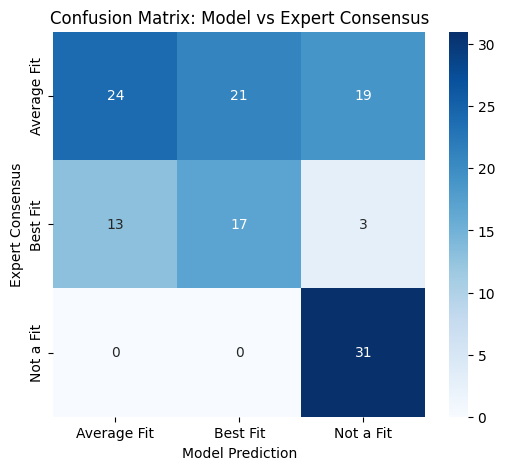

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Visualize confusion matrix for model vs expert consensus
consensus_df = df[df['Expert_Consensus'] != 'Ambiguous']
y_true = consensus_df['Expert_Consensus']
y_pred = consensus_df['Fitness(model)']

labels = sorted(df['Fitness(model)'].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Model Prediction')
plt.ylabel('Expert Consensus')
plt.title('Confusion Matrix: Model vs Expert Consensus')
plt.show()